In [42]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt
from itertools import islice
import json

from cryo_sbi.wpa_simulator.cryo_em_simulator import cryo_em_simulator
from cryo_sbi import CryoEmSimulator
from cryo_sbi.inference.models import build_models
import cryo_sbi.utils.estimator_utils as est_utils
from cryo_sbi.inference.priors import get_image_priors, PriorLoader

In [43]:
def evaluate_log_prob(
    estimator: torch.nn.Module,
    images: torch.Tensor,
    theta: torch.Tensor,
    batch_size: int = 0,
    device: str = "cpu",
) -> torch.Tensor:
    """
    Evaluates the log probability of a given set of images under a given estimator.

    Args:
        estimator (torch.nn.Module): The posterior model to use for evaluation.
        images (torch.Tensor): The input images used to condition the posterior.
        theta (torch.Tensor): The parameter values at which to evaluate the log probability.
        batch_size (int, optional): The batch size for batching the images. Defaults to 0.
        device (str, optional): The device to use for computation. Defaults to "cpu".

    Returns:
        torch.Tensor: The log probabilities of the images under the estimator.
    """

    # batching images if necessary
    
    if images.shape[0] > batch_size and batch_size > 0:
        images = torch.split(images, split_size_or_sections=batch_size, dim=0)
         
    else:
        batch_size = images.shape[0]
        images = [images]


    # theta dimensions [num_eval, num_images, 1]
    if theta.ndim == 3:
        num_eval = theta.shape[0]
        num_images = images.shape[0]
        assert theta.shape == torch.Size([num_eval, num_images, 1])

    elif theta.ndim == 2:
        raise IndexError("theta must have 3 dimensions [num_eval, num_images, 1]")

    elif theta.ndim == 1:
        theta = theta.reshape(-1, 1, 1).repeat(1, batch_size, 1)

    log_probs = []
    for image_batch in images:
        posterior = estimator.flow(image_batch.to(device))
        log_probs.append(posterior.log_prob(estimator.standardize(theta.to(device))))

    log_probs = torch.cat(log_probs, dim=1)
    return log_probs

In [118]:
device = 'cuda'
batch_size = 32
train_config = "../training_parameters_nle.json"
train_config = json.load(open(train_config))
models = torch.load("../models.pt")
images = torch.load("../images.pt")
print(models.shape)
print(images.shape)
device = "cuda"
models = models.to(device)
estimator.to(device) 

torch.Size([100, 3, 4])
torch.Size([5000, 64, 64])


NLEWithEmbedding(
  (nle): NPE(
    (flow): NSF(
      (transform): LazyComposedTransform(
        (0-1): 2 x ElementWiseTransform(
          (base): MonotonicRQSTransform(bins=8)
          (hyper): MLP(
            (0): Linear(in_features=128, out_features=128, bias=True)
            (1): LeakyReLU(negative_slope=0.1)
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): LeakyReLU(negative_slope=0.1)
            (4): Linear(in_features=128, out_features=128, bias=True)
            (5): LeakyReLU(negative_slope=0.1)
            (6): Linear(in_features=128, out_features=64, bias=True)
            (7): LeakyReLU(negative_slope=0.1)
            (8): Linear(in_features=64, out_features=23, bias=True)
          )
        )
      )
      (base): UnconditionalDistribution(DiagNormal(loc: tensor([0.], device='cuda:0'), scale: tensor([1.], device='cuda:0')))
    )
  )
  (embedding): GNN(
    (edge_mlp): Sequential(
      (0): Linear(in_features=1, out_features=6

In [45]:
estimator = build_models.build_nle_flow_model(train_config)
estimator.to(device) 
estimator.eval()

NLEWithEmbedding(
  (nle): NPE(
    (flow): NSF(
      (transform): LazyComposedTransform(
        (0-1): 2 x ElementWiseTransform(
          (base): MonotonicRQSTransform(bins=8)
          (hyper): MLP(
            (0): Linear(in_features=128, out_features=128, bias=True)
            (1): LeakyReLU(negative_slope=0.1)
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): LeakyReLU(negative_slope=0.1)
            (4): Linear(in_features=128, out_features=128, bias=True)
            (5): LeakyReLU(negative_slope=0.1)
            (6): Linear(in_features=128, out_features=64, bias=True)
            (7): LeakyReLU(negative_slope=0.1)
            (8): Linear(in_features=64, out_features=23, bias=True)
          )
        )
      )
      (base): UnconditionalDistribution(DiagNormal(loc: tensor([0.], device='cuda:0'), scale: tensor([1.], device='cuda:0')))
    )
  )
  (embedding): GNN(
    (edge_mlp): Sequential(
      (0): Linear(in_features=1, out_features=6

In [5]:
#models_r = models.transpose(1, 2)
#print(models_r.shape)

In [6]:
#likelihood = estimator.flow(images.to(device)).log_prob(models_r.to(device))
#log_probs.append(posterior.log_prob(estimator.standardize(theta.to(device))))
        


In [33]:
theta = models
print(theta.shape)

torch.Size([100, 3, 4])


In [34]:
theta.ndim

3

In [37]:
if theta.ndim == 3:
    num_eval = theta.shape[0]
    print(num_eval)
    num_images = images.shape[0]
    print(num_images)
    assert theta.shape == torch.Size([num_eval, num_images, 1])

100
5000


AssertionError: 

In [19]:
len(images_split)

157

In [20]:
images.shape

torch.Size([5000, 64, 64])

In [8]:
if images.shape[0] > batch_size and batch_size > 0:
    print('yes')
    print(images.shape)
    images = torch.split(images, split_size_or_sections=batch_size, dim=0)
    print(np.shape(images))
    
         
else:
    batch_size = images.shape[0]
    images = [images]
    print('yes')


    # theta dimensions [num_eval, num_images, 1]
if theta.ndim == 3:
    num_eval = theta.shape[0]
    num_images = images.shape[0]
    print('yes')
    assert theta.shape == torch.Size([num_eval, num_images, 1])

elif theta.ndim == 2:
    raise IndexError("theta must have 3 dimensions [num_eval, num_images, 1]")

elif theta.ndim == 1:
    theta = theta.reshape(-1, 1, 1).repeat(1, batch_size, 1)

log_probs = []
for theta_batch in theta:
    posterior = estimator.flow(theta_batch.to(device))
    log_probs.append(posterior.log_prob(images.to(device)))

#log_probs = torch.cat(log_probs, dim=1)

yes
torch.Size([5000, 64, 64])


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (157,) + inhomogeneous part.

In [32]:
batch_size = 32
if images.shape[0] > batch_size and batch_size > 0:
    #print(images.shape)
    images_split = torch.split(images, split_size_or_sections=batch_size, dim=0)
    #print(np.shape(images_split[0]))

if theta.shape[0] > batch_size and batch_size > 0:
    print(theta.shape)
    theta = theta.transpose(1, 2)
    theta_split = torch.split(theta, split_size_or_sections=batch_size, dim=0)
    print(np.shape(theta_split[0]))

log_probs = []
for theta_batch in theta_split:
    print(theta_batch.shape)
    for image_batch in images_split:
        print(image_batch.shape)
        posterior = estimator.flow(theta_batch.to(device))
        log_probs.append(posterior.log_prob(image_batch.to(device)))

torch.Size([100, 4, 3])
torch.Size([32, 3, 4])
torch.Size([32, 3, 4])
torch.Size([32, 64, 64])


RuntimeError: The size of tensor a (32) must match the size of tensor b (64) at non-singleton dimension 1

In [56]:
def evaluate_log_prob(estimator, images, models, device="cpu"):
    """
    Computes the log-likelihood matrix: all θ × all images.
    Flow is conditioned on theta (NLE setup).

    Args:
        estimator: NLEWithEmbedding trained model
        images: torch.Tensor of shape [num_images, H, W]
        theta: torch.Tensor of shape [num_thetas, ...]
        device: device to compute on

    Returns:
        log_probs: [num_thetas, num_images] tensor
    """
    estimator.eval()
    num_images = images.shape[0]
    num_thetas = models.shape[0]
    print(num_images)
    print(num_thetas)

    log_probs_all = torch.empty(num_thetas, num_images)

    with torch.no_grad():
        image_flat = images.view(1, -1).to(device)
        print(image_flat.shape)
        posterior = estimator.flow(models.to(device))  
        print(images.shape)
        print(models.shape)
        log_probs_all = posterior.log_prob(image_flat)

    return log_probs_all

In [59]:
def evaluate_log_prob_2(estimator, images, theta, device="cpu"):
    """
    Computes the log-likelihood matrix: all θ × all images.
    Flow is conditioned on theta (NLE setup).

    Args:
        estimator: NLEWithEmbedding trained model
        images: torch.Tensor of shape [num_images, C, H, W]
        theta: torch.Tensor of shape [num_thetas, param_dim]
        device: device to compute on

    Returns:
        log_probs: [num_thetas, num_images] tensor
    """
    estimator.eval()
    images = images.to(device)
    theta = theta.to(device)
    
    num_images = images.shape[0]
    num_thetas = theta.shape[0]

    log_probs_all = torch.empty(num_thetas, num_images)

    with torch.no_grad():
        # Compute θ-conditioned flows for all θ at once
        # The flow distribution returns log_prob for a batch of images
        for img_idx, image in enumerate(images):
            # Keep image in its original shape, add batch dim
            image_batch = image.unsqueeze(0)  # [1, C, H, W]
            
            # Compute log-probs for this image under all θ
            log_probs = estimator(image_batch.repeat(num_thetas, 1, 1, 1), theta)
            # log_probs shape: [num_thetas, 1], squeeze to [num_thetas]
            log_probs_all[:, img_idx] = log_probs.squeeze(-1).cpu()

    return log_probs_all


In [60]:
samples = evaluate_log_prob_2(estimator, images, models)

In [61]:
samples.shape

torch.Size([100, 5000])

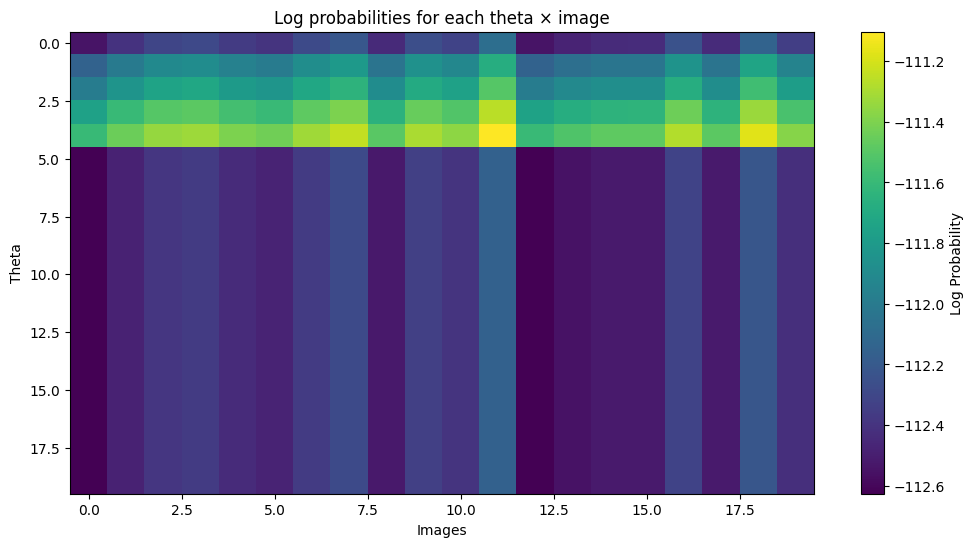

In [66]:
plt.figure(figsize=(12, 6))
plt.imshow(samples[:20, :20], aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image')
plt.show()

In [20]:
device = 'cuda'
image_config = json.load(open("../simulation_parameters.json"))
image_prior = get_image_priors(len(models) - 1, image_config, device="cpu")
prior_loader = PriorLoader(image_prior, batch_size=160, num_workers=4)
num_pixels = torch.tensor(image_config["N_PIXELS"], dtype=torch.float32, device=device)
pixel_size = torch.tensor(image_config["PIXEL_SIZE"], dtype=torch.float32, device=device)

In [94]:
def evaluate_log_prob_nle_training_style(
    estimator: torch.nn.Module,
    images,
    models: torch.Tensor,
    train_config,
    device: str = "cuda",
) -> torch.Tensor:
    """
    Evaluate log-likelihoods in batches, similar to the training loop, explicitly using flows.

    Args:
        estimator: Trained NLEWithEmbedding model.
        prior_loader: Iterable over θ parameters (like in training).
        models: The set of models used for cryo-EM simulation.
        num_pixels: Image size.
        pixel_size: Pixel size.
        train_config: Training configuration dict with 'BATCH_SIZE'.
        device: Device for computation.

    Returns:
        log_probs_all: Tensor of log-likelihoods [num_theta_total, batch_size]
    """
    estimator.eval()
    log_probs_list = []

    with torch.no_grad():
        for _images, _models in zip(
            images.split(train_config["BATCH_SIZE"]),
            models.split(train_config["BATCH_SIZE"]),
        ):
            print("images:", images.shape)
            print("models:", models.shape)
                
            _models = _models.to(device)
            _images = _images.to(device)

            #models_selected = models[_indices.round().long().flatten()]
            #models_selected = models_selected.to(device)
            models_selected = _models.transpose(1, 2)
            print('test',models_selected.shape)

            log_prob_batch = estimator.forward(_images,models_selected)
            log_probs_list.append(log_prob_batch.cpu())

    # Concatenate all mini-batch results
    log_probs_all = torch.cat(log_probs_list, dim=0)
    return log_probs_all


In [95]:
samples = evaluate_log_prob_nle_training_style(estimator, images, models, train_config)

images: torch.Size([5000, 64, 64])
models: torch.Size([100, 3, 4])
test torch.Size([32, 4, 3])
images: torch.Size([5000, 64, 64])
models: torch.Size([100, 3, 4])
test torch.Size([32, 4, 3])
images: torch.Size([5000, 64, 64])
models: torch.Size([100, 3, 4])
test torch.Size([32, 4, 3])
images: torch.Size([5000, 64, 64])
models: torch.Size([100, 3, 4])
test torch.Size([4, 4, 3])


RuntimeError: Attempting to broadcast a dimension of length 4 at -1! Mismatching argument at index 1 had torch.Size([4]); but expected shape should be broadcastable to [32]

In [63]:
import torch
from tqdm import tqdm

def evaluate_log_prob_nle_precomputed(
    estimator: torch.nn.Module,
    images: torch.Tensor,
    models: torch.Tensor,
    device: str = "cuda",
) -> torch.Tensor:
    """
    Evaluate log-likelihoods for precomputed cryo-EM images using an NLE model,
    in the same style as the training loop (but without generating images).

    Args:
        estimator: Trained NLEWithEmbedding model.
        images: Tensor of shape [N, C, H, W] – precomputed images.
        models: Tensor of shape [N, param_dim, ...] – corresponding conditioning variables.
        train_config: Dict with "BATCH_SIZE".
        device: Device for computation.

    Returns:
        log_probs_all: [N] tensor of log-likelihoods.
    """

    estimator.eval()
    log_probs_list = []

    with torch.no_grad():
        # Split data into mini-batches as in training
        for _images, _models in zip(
            images.split(train_config["BATCH_SIZE"]),
            models.split(train_config["BATCH_SIZE"]),
        ):
            _images = _images.to(device, non_blocking=True)
            _models = _models.to(device, non_blocking=True)

            models_selected = models[_indices.round().long().flatten()]
                models_selected = models_selected.to(device)
                models_selected = models_selected.transpose(1, 2)

            # Just as in training: image is input, model (structure) is conditioning variable
            log_prob_batch = estimator.forward(_images, _models)

            log_probs_list.append(log_prob_batch)

    log_probs_all = torch.cat(log_probs_list, dim=0)
    return log_probs_all


IndentationError: unexpected indent (3537701474.py, line 38)

In [65]:
samples = evaluate_log_prob_nle_training_style(estimator, images, models, train_config)

NameError: name 'indices' is not defined

In [36]:
samples = evaluate_log_prob_nle_training_style(estimator,
    prior_loader,
    models,
    num_pixels,
    pixel_size,
    train_config , device = 'cuda'                                            )

KeyboardInterrupt: 

In [108]:
N_images = images.shape[0]
N_models = models.shape[0]

images = images.to(device)
models = models.to(device)
estimator.to(device)

log_probs = torch.empty(N_models, N_images)

with torch.no_grad():
    for i, model in enumerate(models):
        #print(i, model.shape)
        # model shape: [3,4], expand to batch
        model_batch = model.unsqueeze(0).repeat(N_images, 1, 1)
        print(model_batch)
        print(images.shape)
        log_probs[i] = estimator.forward(images, model_batch).cpu()


tensor([[[0., -0., 0., -0.],
         [0., 0., -0., -0.],
         [0., 0., 0., 0.]],

        [[0., -0., 0., -0.],
         [0., 0., -0., -0.],
         [0., 0., 0., 0.]],

        [[0., -0., 0., -0.],
         [0., 0., -0., -0.],
         [0., 0., 0., 0.]],

        ...,

        [[0., -0., 0., -0.],
         [0., 0., -0., -0.],
         [0., 0., 0., 0.]],

        [[0., -0., 0., -0.],
         [0., 0., -0., -0.],
         [0., 0., 0., 0.]],

        [[0., -0., 0., -0.],
         [0., 0., -0., -0.],
         [0., 0., 0., 0.]]], device='cuda:0')
torch.Size([5000, 64, 64])
tensor([[[ 0.5051, -0.5051,  0.5051, -0.5051],
         [ 0.5051,  0.5051, -0.5051, -0.5051],
         [ 0.0000,  0.0000,  0.0000,  0.0000]],

        [[ 0.5051, -0.5051,  0.5051, -0.5051],
         [ 0.5051,  0.5051, -0.5051, -0.5051],
         [ 0.0000,  0.0000,  0.0000,  0.0000]],

        [[ 0.5051, -0.5051,  0.5051, -0.5051],
         [ 0.5051,  0.5051, -0.5051, -0.5051],
         [ 0.0000,  0.0000,  0.0000,  0.

In [105]:
log_probs.shape

torch.Size([100, 5000])

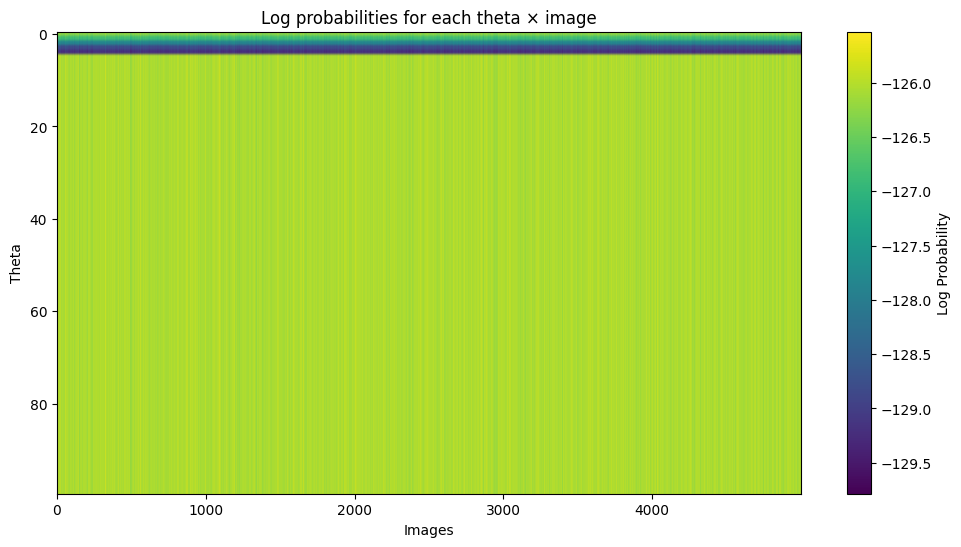

In [107]:
plt.figure(figsize=(12, 6))
plt.imshow(log_probs, aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image')
plt.show()

In [110]:
device = 'cuda'
image_config = json.load(open("../simulation_parameters.json"))
image_prior = get_image_priors(len(models) - 1, image_config, device="cpu")
prior_loader = PriorLoader(image_prior, batch_size=160, num_workers=4)
num_pixels = torch.tensor(image_config["N_PIXELS"], dtype=torch.float32, device=device)
pixel_size = torch.tensor(image_config["PIXEL_SIZE"], dtype=torch.float32, device=device)

In [109]:
def evaluate_log_prob_nle_training_style(
    estimator: torch.nn.Module,
    prior_loader,
    models: torch.Tensor,
    num_pixels: int,
    pixel_size: float,
    train_config: dict,
    device: str = "cuda",
) -> torch.Tensor:
    """
    Evaluate log-likelihoods in batches, similar to the training loop.

    Args:
        estimator: Trained NLEWithEmbedding model.
        prior_loader: Iterable over θ parameters (like in training).
        models: The set of models used for cryo-EM simulation.
        num_pixels: Image size.
        pixel_size: Pixel size.
        train_config: Training configuration dict with 'BATCH_SIZE'.
        device: Device for computation.

    Returns:
        log_probs_all: Tensor of log-likelihoods [num_theta_total, batch_size]
    """
    estimator.eval()
    log_probs_list = []

    with torch.no_grad():
        for parameters in prior_loader:
            (
                indices,
                quaternions,
                res,
                shift,
                defocus,
                b_factor,
                amp,
                snr,
            ) = parameters

            # Simulate images for this batch of θs
            images = cryo_em_simulator(
                models,
                indices.to(device, non_blocking=True),
                quaternions.to(device, non_blocking=True),
                res.to(device, non_blocking=True),
                shift.to(device, non_blocking=True),
                defocus.to(device, non_blocking=True),
                b_factor.to(device, non_blocking=True),
                amp.to(device, non_blocking=True),
                snr.to(device, non_blocking=True),
                num_pixels,
                pixel_size,
            )

            # Loop over smaller batches (as in training)
            for _indices, _images in zip(
                indices.split(train_config["BATCH_SIZE"]),
                images.split(train_config["BATCH_SIZE"]),
            ):
                models_selected = models[_indices.round().long().flatten()]
                models_selected = models_selected.transpose(1, 2)

                # Evaluate log-likelihood for this mini-batch
                log_prob_batch = estimator(
                    _images.to(device, non_blocking=True),
                    models_selected.to(device, non_blocking=True),
                )
                log_probs_list.append(log_prob_batch.cpu())

    # Concatenate all mini-batch results
    log_probs_all = torch.cat(log_probs_list, dim=0)
    return log_probs_all


In [112]:
samples = evaluate_log_prob_nle_training_style(estimator, prior_loader,models,
    num_pixels,
    pixel_size,train_config)


KeyboardInterrupt: 

In [166]:
def evaluate_log_prob_nle_precomputed(
    estimator: torch.nn.Module,
    images: torch.Tensor,
    models: torch.Tensor,
    batch_size: int = 32,
    device: str = "cuda",
):
    estimator.eval()
    images = images.to(device)
    models = models.to(device)
    log_probs_list = []

    with torch.no_grad():
        for _images, _models in zip(images.split(train_config["BATCH_SIZE"]),models.split(train_config["BATCH_SIZE"])):
            B = _images.shape[0]  # may be smaller than batch_size in last batch
            _images = _images.to(device)
            _models = _models.to(device)[:B]  # ensure shapes match

   
            #_models_flat = _models.view(B, -1)

            log_prob_batch = estimator.forward(_images, _models)
            log_probs_list.append(log_prob_batch.cpu())

            log_probs_all = torch.cat(log_probs_list, dim=0)
    return log_probs_all


In [167]:
models.shape

torch.Size([100, 3, 4])

In [180]:
def evaluate_log_prob(estimator, images, theta, device="cuda"):
    """
    Computes the log-likelihood matrix: all θ × all images.
    Flow is conditioned on theta (NLE setup).

    Args:
        estimator: NLEWithEmbedding trained model
        images: torch.Tensor of shape [num_images, C, H, W]
        theta: torch.Tensor of shape [num_thetas, param_dim]
        device: device to compute on

    Returns:
        log_probs: [num_thetas, num_images] tensor
    """
    estimator.eval()
    images = images.to(device)
    theta = theta.to(device)
    
    num_images = images.shape[0]
    num_thetas = theta.shape[0]

    log_probs_all = []

    with torch.no_grad():
        # Compute θ-conditioned flows for all θ at once
        # The flow distribution returns log_prob for a batch of images
        for img_idx, image in enumerate(images):
            # Keep image in its original shape, add batch dim
            image_batch = image.unsqueeze(0)  # [1, C, H, W]
            
            # Compute log-probs for this image under all θ
            log_probs = estimator(image_batch.repeat(num_thetas, 1, 1, 1), theta)
            # log_probs shape: [num_thetas, 1], squeeze to [num_thetas]
            log_probs_all.append(log_probs.squeeze(-1).cpu())

    return log_probs_all


In [181]:
samples = evaluate_log_prob(estimator, images, models)

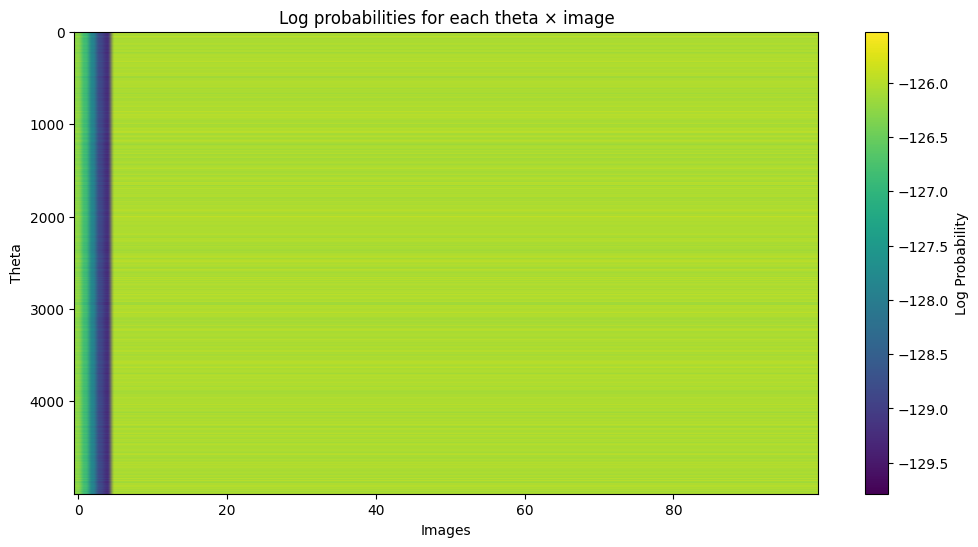

In [182]:
plt.figure(figsize=(12, 6))
plt.imshow(samples, aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image')
plt.show()